# LangGraph fundamentals

In [1]:
# setting the environment variables, the keys
import sys
import os

sys.path.insert(0, os.path.abspath(".."))

from config import set_environment

# for the keys - as explained early in chapter 2
set_environment()

Let's start with creating an agent that analyzes a provided job description and if it fits my profile, it generated an application. We'll fake the application logic itself, and work only on the flow for now:

In [2]:
from langchain_google_vertexai import ChatVertexAI
llm = ChatVertexAI(model="gemini-2.5-flash")

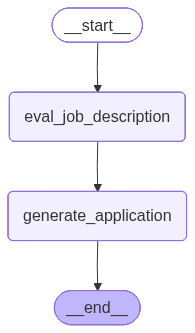

In [3]:
from typing_extensions import TypedDict

class JobApplicationState(TypedDict):
    job_description: str
    is_suitable: bool
    application: str

from langgraph.graph import StateGraph, START, END, Graph

def eval_job_description(state: JobApplicationState):
    print("...Analysing a provided job description...")
    return {"is_suitable": len(state["job_description"]) > 100}

def generate_application(state: JobApplicationState):
    print("...Generating a job application...")
    job_description = state["job_description"]
    return {"application": f"some_fake_application"}

builder = StateGraph(JobApplicationState)
builder.add_node("eval_job_description", eval_job_description)
builder.add_node("generate_application", generate_application)

builder.add_edge(START, "eval_job_description")
builder.add_edge("eval_job_description", "generate_application")
builder.add_edge("generate_application", END)

graph = builder.compile()

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

As we can see, our graph is a *Runnable*.

In [4]:
from langchain_core.runnables import Runnable
isinstance(graph, Runnable)

True

Hence, we can run it like any *Runnable*:

In [5]:
res = graph.invoke({"job_description": "fake_jd"})
print(res)

...Analysing a provided job description...
...Generating a job application...
{'job_description': 'fake_jd', 'is_suitable': False, 'application': 'some_fake_application'}


## Add Conditional Edges
Now, let's make our logic a little bit more complex and make an edge conditional - in other words, our flow would depend on the previous outcomes (of an LLM):

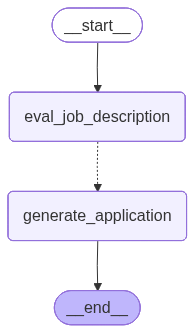

In [6]:
from typing import Literal

builder = StateGraph(JobApplicationState)
builder.add_node("eval_job_description", eval_job_description)
builder.add_node("generate_application", generate_application)

def is_suitable_condition(state: JobApplicationState) -> Literal["generate_application", END]:
    if state.get("is_suitable"):
        return "generate_application"
    return END

builder.add_edge(START, "eval_job_description")
builder.add_conditional_edges("eval_job_description", is_suitable_condition)
builder.add_edge("generate_application", END)

graph = builder.compile()

from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

## Option 1: State with accumulating values via default reducer
Let's see how we can defined state fields that accumulate values. The first option is to use a default reducer that replaces the values in the state:

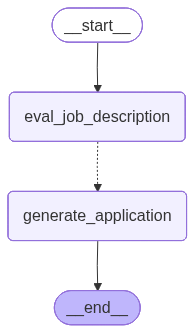

In [7]:
class JobApplicationState(TypedDict):
    job_description: str
    is_suitable: bool
    application: str
    actions: list[str]

def eval_job_description(state: JobApplicationState) -> dict[str, object]:
    print("...Analysing a provided job description...")
    result = {
        "is_suitable": len(state["job_description"]) < 100,
        "actions": ["action1"]
    }
    return result

def generate_application(state: JobApplicationState) -> dict[str, object]:
    print("...Generating a job application...")
    return {"application": "some_fake_application", "actions": ["action2"]}

builder = StateGraph(JobApplicationState)
builder.add_node("eval_job_description", eval_job_description)
builder.add_node("generate_application", generate_application)

builder.add_edge(START, "eval_job_description")
builder.add_conditional_edges("eval_job_description", is_suitable_condition)
builder.add_edge("generate_application", END)

graph = builder.compile()

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [8]:
async for chunk in graph.astream(
    input={"job_description":"fake_jd"},
    stream_mode="values"
):
    print(chunk)
    print("\n\n")

{'job_description': 'fake_jd'}



...Analysing a provided job description...
{'job_description': 'fake_jd', 'is_suitable': True, 'actions': ['action1']}



...Generating a job application...
{'job_description': 'fake_jd', 'is_suitable': True, 'application': 'some_fake_application', 'actions': ['action2']}





## Option 2 - use `add` method as a reducer (Adds to the list):

Another option is to use the default add method with the Annotated type hint. By using this type hint, we tell the LangGraph compiler that the type of our variable in the state is a list of strings, and it should use the add method to concatenate two lists

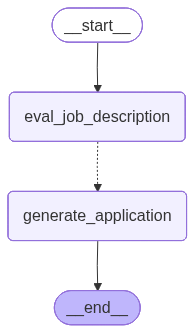

In [9]:
from typing import Annotated, Optional
from operator import add

class JobApplicationState(TypedDict):
    job_description: str
    is_suitable: bool
    application: str
    actions: Annotated[list[str], add]

def eval_job_description(state: JobApplicationState) -> dict[str, object]:
    print("...Analysing a provided job description...")
    result = {
        "is_suitable": len(state["job_description"]) < 100,
        "actions": ["action1"],
    }
    return result

def generate_application(state: JobApplicationState) -> dict[str, object]:
    print("...Generating a job application...")
    return {"application": "some_fake_application", "actions": ["action2"]}

builder = StateGraph(JobApplicationState)
builder.add_node("eval_job_description", eval_job_description)
builder.add_node("generate_application", generate_application)

builder.add_edge(START, "eval_job_description")
builder.add_conditional_edges("eval_job_description", is_suitable_condition)
builder.add_edge("generate_application", END)

graph = builder.compile()

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [10]:
async for chunk in graph.astream(
    input={"job_description":"fake_jd"},
    stream_mode="values"
):
    print(chunk)
    print("\n\n")

{'job_description': 'fake_jd', 'actions': []}



...Analysing a provided job description...
{'job_description': 'fake_jd', 'is_suitable': True, 'actions': ['action1']}



...Generating a job application...
{'job_description': 'fake_jd', 'is_suitable': True, 'application': 'some_fake_application', 'actions': ['action1', 'action2']}





## Option 3: And the last option is to build your own custom reducer

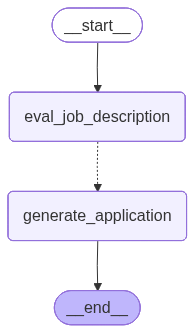

In [11]:
from typing import Annotated, Optional, Union
from operator import add

def my_reducer(left: list[str], right: Optional[Union[str, list[str]]]) -> list[str]:
    if right:
        return left + [right] if isinstance(right, str) else left + right
    return left

class JobApplicationState(TypedDict):
    job_description: str
    is_suitable: bool
    application: str
    actions: Annotated[list[str], my_reducer]

def eval_job_description(state: JobApplicationState) -> dict[str, object]:
    print("...Analysing a provided job description...")
    result = {
        "is_suitable": len(state["job_description"]) < 100,
        "actions": "action1",
    }
    return result

def generate_application(state: JobApplicationState) -> dict[str, object]:
    print("...Generating a job application...")
    return {"application": "some_fake_application", "actions": ["action2", "action3"]}


builder = StateGraph(JobApplicationState)
builder.add_node("eval_job_description", eval_job_description)
builder.add_node("generate_application", generate_application)
builder.add_edge(START, "eval_job_description")
builder.add_conditional_edges("eval_job_description", is_suitable_condition)
builder.add_edge("generate_application", END)

graph = builder.compile()

from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [12]:
async for chunk in graph.astream(
    input={"job_description":"fake_jd"},
    stream_mode="values"
):
    print(chunk)
    print("\n\n")

{'job_description': 'fake_jd', 'actions': []}



...Analysing a provided job description...
{'job_description': 'fake_jd', 'is_suitable': True, 'actions': ['action1']}



...Generating a job application...
{'job_description': 'fake_jd', 'is_suitable': True, 'application': 'some_fake_application', 'actions': ['action1', 'action2', 'action3']}





## Graph Configuration
How we can add configuration to our graph:

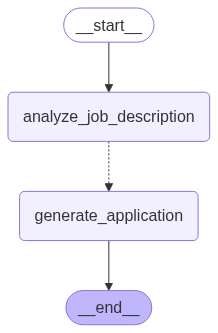

In [13]:
from langchain_core.runnables.config import RunnableConfig

def generate_application(state: JobApplicationState, config: RunnableConfig):
    model_provider = config["configurable"].get("model_provider", "Google")
    model_name = config["configurable"].get("model_name", "gemini-2.5-flash")
    print(f"...Generating a job application with {model_provider} {model_name}...")
    return {"application": "some_fake_application", "actions": ["actions2", "actions3"]}


builder = StateGraph(JobApplicationState)
builder.add_node("analyze_job_description", eval_job_description)
builder.add_node("generate_application", generate_application)
builder.add_edge(START, "analyze_job_description")
builder.add_conditional_edges("analyze_job_description", is_suitable_condition)
builder.add_edge("generate_application", END)

graph = builder.compile()

from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [14]:
res = graph.invoke({"job_description":"fake_jd"})
print(res)

...Analysing a provided job description...
...Generating a job application with Google gemini-2.5-flash...
{'job_description': 'fake_jd', 'is_suitable': True, 'application': 'some_fake_application', 'actions': ['action1', 'actions2', 'actions3']}


In [15]:
res = graph.invoke({"job_description":"fake_jd"}, config={"configurable": {"model_provider": "OpenAI", "model_name": "gpt-4o"}})
print(res)

...Analysing a provided job description...
...Generating a job application with OpenAI gpt-4o...
{'job_description': 'fake_jd', 'is_suitable': True, 'application': 'some_fake_application', 'actions': ['action1', 'actions2', 'actions3']}
